[{'alpha': 0, 'accuracy_score': {'mean': 0.5950127877237852, 'std': 0.003337081419616351}}, {'alpha': 1, 'accuracy_score': {'mean': 0.5826086956521739, 'std': 0.0024397422031123953}}, {'alpha': 2, 'accuracy_score': {'mean': 0.5835038363171355, 'std': 0.002143613122025592}}, {'alpha': 3, 'accuracy_score': {'mean': 0.5831202046035806, 'std': 0.0019810656502339853}}, {'alpha': 4, 'accuracy_score': {'mean': 0.5836317135549872, 'std': 0.002439742203112392}}, {'alpha': 5, 'accuracy_score': {'mean': 0.5805626598465474, 'std': 0.001617533330009385}}, {'alpha': 6, 'accuracy_score': {'mean': 0.6180306905370844, 'std': 0.001901031809119998}}, {'alpha': 7, 'accuracy_score': {'mean': 0.6193520886615516, 'std': 0.001044113274843612}}, {'alpha': 8, 'accuracy_score': {'mean': 0.618158567774936, 'std': 0.0008482416343619726}}, {'alpha': 9, 'accuracy_score': {'mean': 0.6180306905370843, 'std': 0.0015184580673961443}}, {'alpha': 10, 'accuracy_score': {'mean': 0.619309462915601, 'std': 0.00128515033518168

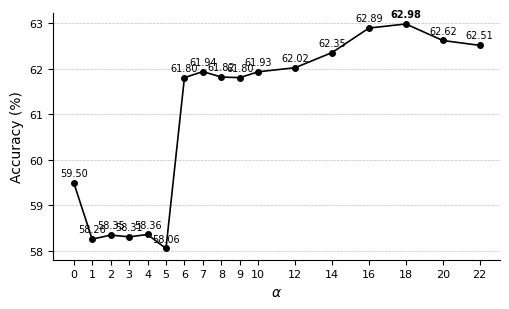

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json



def plot_alpha_sensitivity(results, save_path=None):
    alphas = [r["alpha"] for r in results]
    accuracies = [
        r["accuracy_score"]["mean"] * 100
        for r in results
    ]
    best_idx = np.argmax(accuracies)
    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    ax.plot(
        alphas,
        accuracies,
        "-o",
        color="black",
        linewidth=1.2,
        markersize=4
    )
    for i, (alpha, accuracy) in enumerate(zip(alphas, accuracies)):
        ax.annotate(
            f"{accuracy:.2f}",
            (alpha, accuracy),
            textcoords="offset points",
            xytext=(0, 5),
            ha="center",
            fontsize=7,
            fontweight="bold" if i == best_idx else "normal"
        )
    ax.set_xlabel(r"$\alpha$", fontsize=10)
    ax.set_ylabel("Accuracy (%)", fontsize=10)
    ax.set_xticks(alphas)
    ax.tick_params(axis="both", labelsize=8)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, color="0.75")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.show()


def read_only_validation_results():
    results = []
    base_dir = Path("results_paper/rf_wpd_sdfs_alpha")
    for experiment_dir in base_dir.iterdir():        
        alpha = int(experiment_dir.name.split("_")[4])
        for result_file in experiment_dir.glob("compiled_results*.json"):
            with open(result_file, "r") as f:
                data = json.load(f)
            results.append({
                "alpha": alpha,
                "accuracy_score": data["domains"]["domains_9"]["accuracy_score"]
            })
    return sorted(results, key=lambda x: x["alpha"])


results = read_only_validation_results()
print(results)
plot_alpha_sensitivity(results)